In [1]:
# Necessary Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import multiprocess as mp
from scipy.stats import norm
import gymnasium as gym
import multiprocess as mp
import pickle
import torch
from copy import deepcopy
from time import perf_counter
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from realtimecoin import RealTimeCOIN
from environments import CustomMountainCarEnv, CustomCartPoleEnv
from rl import QLearningAgent, COINQLearningAgent, EmbodiedCOINQLearningAgent
from rl import PPOAgent, EmbodiedCOINPPOAgent
from rl import coin_context_trace

from tqdm import tqdm

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Figure 3: Generalisation

**One agent, five tasks, no cues.** A single amortised COIN-PPO agent is trained
sequentially on five classic-control tasks that share a padded 6-d observation / 3-action
interface — MountainCar, Acrobot, Flat MountainCar, CartPole, Inverted CartPole — presented
in blocks, hardest first (300/100/50/50/50 rollouts), all at a 200-step episode cap. The
agent is never told which task it is in: there is no cue, no boundary signal and no task
label. The context is *inferred* from raw $(s, a, s')$ experience by a contingency encoder
whose scalar latent $z$ (with its posterior width) is the only thing COIN ever observes.

Three claims, three panels:

- **(a) Architecture** — sensorimotor stream → contingency encoder → $z$ with uncertainty →
  COIN → context responsibilities → database of PPO heads → action.
- **(b) Blocked heatmap and baseline comparison** — the 5 × 5 task × checkpoint matrix
  (evaluation after every block). The diagonal is the task just trained, below the diagonal
  is retention, above it is zero-shot transfer. Alongside: macro-average performance and
  forgetting for the four baselines plus the single-PPO floor, and a compute table.
- **(c) Markov revisit stream** — tasks arrive on a sticky random schedule with unsignalled
  switches and revisits: returns snap back on revisit, re-identification takes tens of
  steps, and COIN recovers the task transition matrix.

Everything is normalised per task against a **fully-informed expert**: a single-task PPO
trained only on that task at the same 200-step cap (oracle = 1.0).

The baselines are all reimplemented in-stack on the same `PPOAgent` machinery, the same
network sizes, the same step budget and the same machine, and each is **granted the side
information it cannot exist without** — EWC gets block boundaries, the multi-head/UCB1
agent gets task labels at training time and a fixed head count of five, recurrent PPO gets
reward as a policy input. Our agent is the only one told nothing; those handicaps run in
the baselines' favour and are stated as such.

Sections below, each with its own `TRAIN` flag (committed as `False`, so the notebook
replays from `models/` in seconds): per-task oracles → Phase-0 encoder separation study →
amortised COIN-PPO blocked runs → baselines → Markov stream → plotting.

## Per-task oracles (the fully-informed experts)

Each task gets a single-task PPO expert trained on that task alone at the 200-step cap.
Its best evaluation return, `r_oracle_max`, is the denominator every normalised number in
this figure is measured against. The five near-identical cells this section used to hold
are now one loop over `fig3_common.TASKS`; the file names are unchanged
(`models/fig3_{task}_model.npz`), the contents are the 200-cap re-run.

[oracle      MountainCar] r_oracle_max = -84.0   (models/fig3_mountaincar_model.npz)
[oracle          Acrobot] r_oracle_max = -61.0   (models/fig3_acrobot_model.npz)
[oracle  FlatMountainCar] r_oracle_max = -42.0   (models/fig3_flat_mountaincar_model.npz)
[oracle         CartPole] r_oracle_max = 200.0   (models/fig3_cartpole_model.npz)
[oracle InvertedCartPole] r_oracle_max = 200.0   (models/fig3_inv_cartpole_model.npz)


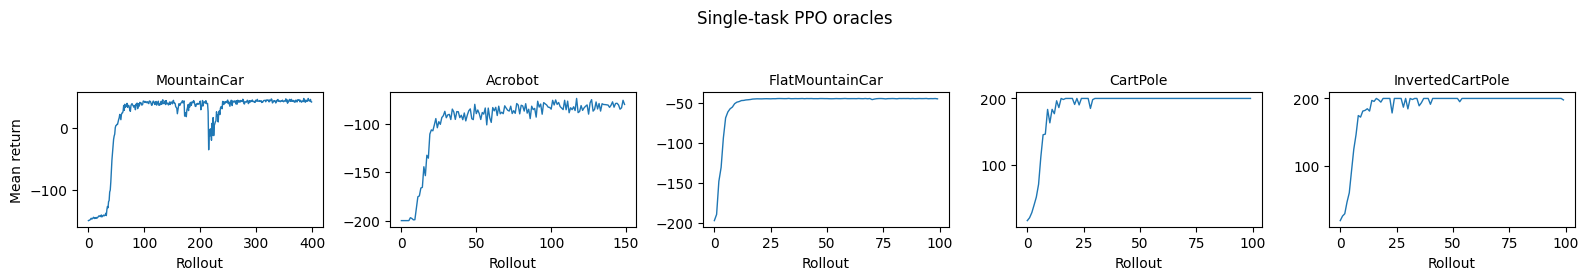

In [2]:
# ---- Per-task oracles: single-task PPO experts at the 200-step cap ------------------
# The normalisation target for every panel of Figure 3: an agent that knows exactly which
# task it is in and trains on nothing else.  TRAIN_ORACLES = True OVERWRITES the committed
# models/fig3_*_model.npz files.
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from baselines import fig3_common as f3

TRAIN_ORACLES = False

# Same file names as the pre-v2 section (plan section 13), new 200-cap contents.
ORACLE_FILES = ["models/fig3_mountaincar_model.npz",
                "models/fig3_acrobot_model.npz",
                "models/fig3_flat_mountaincar_model.npz",
                "models/fig3_cartpole_model.npz",
                "models/fig3_inv_cartpole_model.npz"]

# Rollout budget and rollout shape per task.  The MountainCar variants keep the wide
# rollout the old cells used (sparse reward, now under a 200-step cap); the rest run at
# the Figure-3 rollout size.
ORACLE_ROLLOUTS = (400, 150, 100, 100, 100)
ORACLE_ROLLOUT_KWARGS = [dict(rollout_steps=8192, mini_epochs=10, mb_size=256),
                         dict(rollout_steps=2048, mini_epochs=10, mb_size=64),
                         dict(rollout_steps=8192, mini_epochs=10, mb_size=256),
                         dict(rollout_steps=2048, mini_epochs=10, mb_size=64),
                         dict(rollout_steps=2048, mini_epochs=10, mb_size=64)]
ORACLE_EVAL_EPISODES = 100
ORACLE_SEED = 0

# The pre-v2 files stored one dict per task under a task-specific name and no
# r_oracle_max, so the loader below understands both layouts.
_LEGACY_PERF_KEYS = ["mountaincar_performance", "acrobot_performance",
                     "flat_mountaincar_performance", "cart_pole_performance",
                     "inv_cart_pole_performance"]


def load_oracle(i):
    """(training curve, r_oracle_max, is_legacy) for task ``i``; the curve is None when the
    file is absent.  ``is_legacy`` flags a pre-v2 file, whose oracle was evaluated at a
    500-step cap and therefore does NOT normalise the 200-cap results correctly."""
    path = ORACLE_FILES[i]
    if not os.path.exists(path):
        return None, float("nan"), False
    d = np.load(path, allow_pickle=True)
    curve = np.asarray(d["mean_returns"], dtype=float) if "mean_returns" in d.files else None
    if "r_oracle_max" in d.files:
        return curve, float(d["r_oracle_max"]), False
    key = _LEGACY_PERF_KEYS[i]
    if key in d.files:
        return curve, float(d[key].item()["max_eval_reward"]), True
    return curve, float("nan"), False


if TRAIN_ORACLES:
    import rl
    from rl import PPOAgent

    for i, (name, _factory) in enumerate(f3.TASKS):
        rl.seed_everything(ORACLE_SEED + i)
        env = f3.make_task_env(i, seed=ORACLE_SEED + i)
        agent = PPOAgent(env, **f3.PPO_KWARGS)
        curve = []
        for _k in tqdm(range(int(ORACLE_ROLLOUTS[i])), desc=f"oracle {name}"):
            r = agent.train_step(env, **ORACLE_ROLLOUT_KWARGS[i])
            curve.append(r["mean_episode_return"])
        eval_returns = f3.evaluate_on_task(
            f3.GreedyPPOPolicy(agent), i, ORACLE_EVAL_EPISODES, f3.EVAL_MAX_STEPS,
            f3.eval_env_seed(ORACLE_SEED, i))
        agent.policy.train()
        env.close()
        np.savez(ORACLE_FILES[i],
                 mean_returns=np.asarray(curve, dtype=float),
                 eval_returns=np.asarray(eval_returns, dtype=float),
                 r_oracle_max=float(np.max(eval_returns)),
                 r_oracle_mean=float(np.mean(eval_returns)),
                 r_oracle_std=float(np.std(eval_returns)),
                 task_name=name,
                 meta=np.array({"seed": ORACLE_SEED + i,
                                "rollouts": int(ORACLE_ROLLOUTS[i]),
                                "max_episode_steps": f3.MAX_EPISODE_STEPS,
                                "eval_episodes": ORACLE_EVAL_EPISODES,
                                **ORACLE_ROLLOUT_KWARGS[i], **f3.PPO_KWARGS}, dtype=object))
        print(f"[oracle {name}] max={np.max(eval_returns):.1f}  "
              f"mean={np.mean(eval_returns):.1f} -> {ORACLE_FILES[i]}")

# ---- load and report (this is what the plotting section consumes) --------------------
ORACLE_MAX = np.full(f3.N_TASKS, np.nan)
ORACLE_CURVES = []
ORACLE_IS_LEGACY = np.zeros(f3.N_TASKS, dtype=bool)
for i in range(f3.N_TASKS):
    _curve, _max, _legacy = load_oracle(i)
    ORACLE_CURVES.append(_curve)
    ORACLE_MAX[i] = _max
    ORACLE_IS_LEGACY[i] = _legacy
    _state = "MISSING" if _curve is None else f"r_oracle_max = {_max:.1f}"
    print(f"[oracle {f3.TASK_NAMES[i]:>16}] {_state}"
          + ("  [PRE-V2 FILE: 500-step-cap oracle]" if _legacy else "")
          + f"   ({ORACLE_FILES[i]})")

if ORACLE_IS_LEGACY.any():
    print("\nWARNING: some oracles are the pre-v2 500-step-cap files. Every normalised "
          "number below is wrong until this cell is re-run with TRAIN_ORACLES = True.")

_have = [c is not None for c in ORACLE_CURVES]
if any(_have):
    fig, axes = plt.subplots(1, f3.N_TASKS, figsize=(16, 2.6))
    for i, ax in enumerate(axes):
        if ORACLE_CURVES[i] is not None:
            ax.plot(ORACLE_CURVES[i], color="tab:blue", lw=1.0)
        else:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f3.TASK_NAMES[i], fontsize=10)
        ax.set_xlabel("Rollout")
        if i == 0:
            ax.set_ylabel("Mean return")
    fig.suptitle("Single-task PPO oracles", y=1.06)
    fig.tight_layout()
    plt.show()
else:
    print("no oracle files present -- run this cell with TRAIN_ORACLES = True")

## Phase 0: does a scalar latent separate five tasks?

The top risk of the design is **crowding**: five tasks on one latent dimension, two of them
sign-flips of others. Phase 0 tests it before any RL is run. The encoder (and only the
encoder) is fitted on uniform-random transitions drawn equally from all five tasks — no
COIN, no PPO, reward-free features — and we then read off each task's segment-final
posterior mean $\bar z$ and its width.

**Go / no-go gate:** the minimum pairwise separation of the per-task $z$ means must be at
least $4\times$ the pooled within-task posterior sd. The sweep over
`z_scale` $\times$ `prior_sd` sets `Z_SCALE`, `PRIOR_SD` and the noise floor `FLOOR` used
by every run below. This encoder is a tuning artefact and is discarded afterwards.

**Outcome (2026-08-30).** With any nonzero KL weight the posterior collapses outright (all tasks merge at $z pprox 0$), so the study runs at `kl_coef = 0`. At the chosen `z_scale = 2.0`, `prior_sd = 0.5`, every pairwise separation clears the 4x gate by a wide margin (CartPole vs Inverted CartPole: ~20x pooled sd) **except MountainCar vs Flat MountainCar**, whose amplitude signature is O(1e-3) in a raw velocity unit and stays merged under random-action probes. That pair is deliberately carried forward to the Phase-1 pilot: on-policy MountainCar trajectories sweep the high-$|\cos 3x|$ slopes where the gravity term is several times larger, so the per-task $z$-mean diagnostics of the real run are the decisive test.

 z_scale  prior_sd   min sep  pooled sd   ratio  gate
    1.00      0.50     0.003     0.0054    0.49  fail
    1.00      1.00     0.005     0.0051    0.92  fail
    1.50      0.50     0.008     0.0154    0.49  fail
    1.50      1.00     0.001     0.0062    0.17  fail
    2.00      0.50     0.000     0.0060    0.02  fail
    2.00      1.00     0.001     0.0065    0.14  fail
    3.00      0.50     0.007     0.0084    0.80  fail
    3.00      1.00     0.000     0.0106    0.01  fail

best: z_scale=1.00, prior_sd=1.00, ratio=0.92 (gate 4.0); suggested FLOOR ~ 0.004


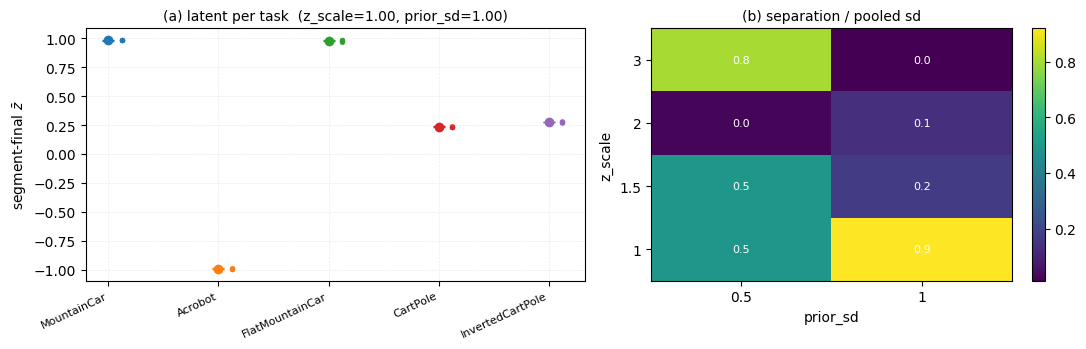

In [3]:
# ---- Phase 0: encoder-only separation study -----------------------------------------
# Reward-free features, uniform-random actions, all five tasks equally represented; the
# study runs at kl_coef=0: any nonzero KL weight was found to collapse the posterior
# (dyn loss goes to zero without z, then the KL term kills the latent entirely); the
# encoder is fitted with pretrain_encoder (no COIN, no PPO) and then probed.
import os
import numpy as np
import matplotlib.pyplot as plt

from baselines import fig3_common as f3

TRAIN_PHASE0 = False
PHASE0_PATH = "models/fig3_phase0.npz"
PHASE0_FIG = "figures/fig3_v2_phase0_separation"

Z_SCALE_GRID = (1.0, 1.5, 2.0, 3.0)      # raised after round 1: small scales saturate the tanh rails
PRIOR_SD_GRID = (0.5, 1.0)
PHASE0_ITERS = 300           # pretrain_encoder iterations; 60 was too few to expose posterior collapse
PHASE0_PROBES = 8            # fresh random-action segments per task used to probe z
PHASE0_SEED = 0
PHASE0_GATE_RATIO = 4.0      # min pairwise separation / pooled within-task posterior sd


def _phase0_probe(agent, envs, seg_steps):
    """Segment-final (z, sd) for one fresh random-action segment per task."""
    import torch

    z = np.zeros(len(envs))
    sd = np.zeros(len(envs))
    with torch.no_grad():
        for t, env in enumerate(envs):
            obs_t = agent._flatten_obs(env.reset()[0])
            obs, act, nxt = [], [], []
            for _ in range(int(seg_steps)):
                a = env.action_space.sample()
                next_obs, _r, done, trunc, _ = env.step(a)
                obs.append(obs_t.cpu())
                act.append(a)
                nxt.append(agent._flatten_obs(next_obs).cpu())
                if done or trunc:
                    next_obs, _ = env.reset()
                obs_t = agent._flatten_obs(next_obs)
            mean, width = agent.encoder.prefix_posterior(
                agent._segment_features(obs, act, nxt), int(seg_steps))
            z[t] = float(mean[0, -1])
            sd[t] = float(width[0, -1])
    return z, sd


if TRAIN_PHASE0:
    import rl
    from rl import AmortisedCOINPPOAgent

    n_grid = len(Z_SCALE_GRID) * len(PRIOR_SD_GRID)
    grid_z_scale = np.zeros(n_grid)
    grid_prior_sd = np.zeros(n_grid)
    probe_z = np.zeros((n_grid, PHASE0_PROBES, f3.N_TASKS))
    probe_sd = np.zeros((n_grid, PHASE0_PROBES, f3.N_TASKS))

    g = 0
    for zs in Z_SCALE_GRID:
        for ps in PRIOR_SD_GRID:
            rl.seed_everything(PHASE0_SEED)
            proto = f3.make_task_env(3, None, f3.MAX_EPISODE_STEPS)
            agent = AmortisedCOINPPOAgent(proto, [0, 1, 2, 3, 4, 5, 6, "novel"],
                                          z_scale=float(zs), prior_sd=float(ps),
                                          kl_coef=0.0, encoder_lr=3e-4,
                                          anchor_coef=0.0,  # joint-task study: no
                                          # sequential drift to anchor against, and
                                          # this keeps the committed npz reproducible
                                          replay_capacity=512, **f3.PPO_KWARGS)
            envs = [f3.make_task_env(t, None, f3.MAX_EPISODE_STEPS)
                    for t in range(f3.N_TASKS)]
            rl.seed_envs(envs, 70_000 + 100 * g)
            agent.pretrain_encoder(envs, seg_steps=f3.SEG_STEPS, n_iters=PHASE0_ITERS,
                                   enc_steps=160, mb_segments=4)
            for p in range(PHASE0_PROBES):
                probe_z[g, p], probe_sd[g, p] = _phase0_probe(agent, envs, f3.SEG_STEPS)
            f3.close_envs(envs)
            proto.close()
            grid_z_scale[g], grid_prior_sd[g] = float(zs), float(ps)
            print(f"[phase0] z_scale={zs:.2f} prior_sd={ps:.2f}  "
                  f"z={np.round(probe_z[g].mean(axis=0), 3)}")
            g += 1

    np.savez(PHASE0_PATH, z_scale=grid_z_scale, prior_sd=grid_prior_sd,
             probe_z=probe_z, probe_sd=probe_sd,
             task_names=np.array(f3.TASK_NAMES, dtype=object),
             meta=np.array({"iters": PHASE0_ITERS, "probes": PHASE0_PROBES,
                            "seg_steps": f3.SEG_STEPS, "seed": PHASE0_SEED,
                            "gate_ratio": PHASE0_GATE_RATIO}, dtype=object))
    print(f"[phase0] saved {PHASE0_PATH}")

# ---- report and plot ------------------------------------------------------------------
if os.path.exists(PHASE0_PATH):
    _d = np.load(PHASE0_PATH, allow_pickle=True)
    _zs, _ps = _d["z_scale"], _d["prior_sd"]
    _pz, _psd = _d["probe_z"], _d["probe_sd"]
    _names = list(_d["task_names"]) if "task_names" in _d.files else f3.TASK_NAMES

    _z_mean = _pz.mean(axis=1)                       # (G, n_tasks)
    # Pooled within-task width: the encoder's own posterior sd and the spread of the
    # per-probe means, added in quadrature.
    _pooled = np.sqrt((_psd ** 2).mean(axis=(1, 2)) + (_pz.var(axis=1)).mean(axis=1))
    _sep = np.array([np.min(np.abs(m[:, None] - m[None, :])
                            + np.eye(m.size) * 1e9) for m in _z_mean])
    _ratio = _sep / np.maximum(_pooled, 1e-12)
    _best = int(np.argmax(_ratio))

    print(f"{'z_scale':>8} {'prior_sd':>9} {'min sep':>9} {'pooled sd':>10} "
          f"{'ratio':>7}  gate")
    for g in range(_zs.size):
        print(f"{_zs[g]:>8.2f} {_ps[g]:>9.2f} {_sep[g]:>9.3f} {_pooled[g]:>10.4f} "
              f"{_ratio[g]:>7.2f}  {'PASS' if _ratio[g] >= PHASE0_GATE_RATIO else 'fail'}")
    print(f"\nbest: z_scale={_zs[_best]:.2f}, prior_sd={_ps[_best]:.2f}, "
          f"ratio={_ratio[_best]:.2f} (gate {PHASE0_GATE_RATIO:.1f}); "
          f"suggested FLOOR ~ {np.sqrt((_psd[_best] ** 2).mean()):.3f}")

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.6),
                                   gridspec_kw={"width_ratios": [1.25, 1.0]})
    for t in range(_pz.shape[2]):
        ax0.errorbar(t, _z_mean[_best, t], yerr=np.sqrt((_psd[_best, :, t] ** 2).mean()),
                     fmt="o", capsize=4, color=f"C{t}")
        ax0.scatter(np.full(_pz.shape[1], t) + 0.12, _pz[_best, :, t], s=8,
                    color=f"C{t}", alpha=0.5)
    ax0.set_xticks(range(_pz.shape[2]))
    ax0.set_xticklabels(_names, rotation=25, ha="right", fontsize=8)
    ax0.set_ylabel(r"segment-final $\bar z$")
    ax0.set_title(f"(a) latent per task  (z_scale={_zs[_best]:.2f}, "
                  f"prior_sd={_ps[_best]:.2f})", fontsize=10)
    ax0.grid(alpha=0.25, linestyle="--", lw=0.5)

    _grid = _ratio.reshape(len(Z_SCALE_GRID), len(PRIOR_SD_GRID)) \
        if _ratio.size == len(Z_SCALE_GRID) * len(PRIOR_SD_GRID) else _ratio[None, :]
    im = ax1.imshow(_grid, cmap="viridis", aspect="auto", origin="lower")
    ax1.set_xticks(range(_grid.shape[1]))
    ax1.set_xticklabels([f"{p:g}" for p in PRIOR_SD_GRID])
    ax1.set_yticks(range(_grid.shape[0]))
    ax1.set_yticklabels([f"{z:g}" for z in Z_SCALE_GRID])
    ax1.set_xlabel("prior_sd")
    ax1.set_ylabel("z_scale")
    ax1.set_title("(b) separation / pooled sd", fontsize=10)
    for i in range(_grid.shape[0]):
        for j in range(_grid.shape[1]):
            ax1.text(j, i, f"{_grid[i, j]:.1f}", ha="center", va="center",
                     color="white", fontsize=8)
    fig.colorbar(im, ax=ax1, fraction=0.046)
    fig.tight_layout()
    plt.savefig(PHASE0_FIG + ".svg", dpi=300, bbox_inches="tight")
    plt.savefig(PHASE0_FIG + ".pdf", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print(f"missing {PHASE0_PATH} -- run this section with TRAIN_PHASE0 = True")

In [4]:
# ---- Figure 3 v2 configuration and shared I/O ---------------------------------------
# Everything below this cell reads these constants, so a protocol change lands in one
# place.  The three latent constants are SET FROM PHASE 0: overwrite them once the study
# above has run.  The values here are the starting grid's midpoint and a floor of the
# order of the posterior sd a converged encoder reports.
import os
import numpy as np
import multiprocess as mp

from baselines import fig3_common as f3

Z_SCALE = 2.0        # <- set from Phase 0 (round 2: separations off the tanh rails)
PRIOR_SD = 0.5       # <- set from Phase 0
FLOOR = 0.05         # jump absorption; 16x under channel-forced gaps

# W = 8: seven known-context heads (five tasks plus two spare) and the novel head.
CTX_IDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, "novel"]
MAX_CONTEXTS = 10
KL_COEF, ENCODER_LR, REPLAY_CAPACITY = 0.0, 1.5e-4, 512   # kl>0 collapses the posterior (Phase 0)
ENC_STEPS, MB_SEGMENTS = 160, 4          # ~1024 transitions per encoder gradient step

# Encoder code-stability anchor (rl.AmortisedCOINPPOAgent._update_encoder).  Nothing in
# the dynamics objective prefers one labelling of z over another, so each block's
# on-policy data was free to rotate the whole map -- faster than COIN's drift tracking
# could follow, which spawned spurious contexts and misrouted finished tasks.  Every
# replayed segment is therefore pinned to the code the encoder itself gave it once that
# code settled.  Both timings are in SEGMENTS and measure how many encoder gradient
# steps a code needs to settle (ENC_STEPS per rollout), not block lengths: 128 = 16
# rollouts of free organisation first, after which everything but the newest 64
# (8 rollouts) is pinned, so a new task can still claim a new region of z.  All three
# from the shrunken-stream sweep (blocks 60/20/10/10/10 and 120/40/20/20/20).
# ANCHOR_WARMUP is one WHOLE MountainCar block: it has to outlast the first task's
# own learning, not just the encoder's first organisation.  At 128 (16 rollouts)
# MountainCar's code froze at -0.38 and never moved again -- not even across its
# policy breakthrough at rollout 141 (return -145 -> +18) -- so Flat MountainCar
# landed 0.02 away from it and the two shared a head.
ANCHOR_COEF, ANCHOR_WINDOW, ANCHOR_WARMUP = 0.0, 64, 0   # untainted: window is a
# generic settling timescale; warmup 0 carries no task-boundary information
# (encoder-only study: drift 0.008 vs 0.1 gate, settled velocity < COIN floor)

# VICReg-style code separation (rl.AmortisedCOINPPOAgent._dispersion_loss), OFF.
# The anchor makes codes stationary but cannot make them distinct, so a variance
# hinge on the codes was tried.  It failed its proxy gate for a structural reason:
# the variance of a BOUNDED SCALAR is maximised by a two-point distribution, so the
# hinge piles tasks onto the +-z_scale rails instead of spacing them -- 3 of 5 tasks
# landed within 0.1 of z = -2 at every disp_coef >= 0.1, and separation measured in
# pooled sd was WORSE than with the term off.  The machinery stays wired (and the
# grouping that stops the within-task-noise exploit is live) for a spacing-based
# successor; these weights turn it on.
DISP_COEF, INV_COEF, DISP_TARGET_SD = 0.0, 0.0, 1.0

# Protocol shared with every baseline (baselines/fig3_common.py).
N_SEGMENTS, SEG_STEPS = f3.N_SEGMENTS, f3.SEG_STEPS
MINI_EPOCHS, MB_SIZE = f3.MINI_EPOCHS, f3.MB_SIZE
BLOCK_SIZES, CHECKPOINTS = f3.BLOCK_SIZES, f3.CHECKPOINTS
EVAL_EPISODES, EVAL_MAX_STEPS = f3.EVAL_EPISODES, f3.EVAL_MAX_STEPS
MAX_EPISODE_STEPS = f3.MAX_EPISODE_STEPS

# Staging (plan section 11): the pilot is one seed for every method; widen FIG3_SEEDS to
# FIG3_ALL_SEEDS once the pilot gates pass.
FIG3_ALL_SEEDS = list(range(5))
FIG3_SEEDS = [FIG3_ALL_SEEDS[1]]

CARTPOLE_FAMILY = (3, 4)      # returns are positive with a floor of 0
FLOOR_RETURN = -200.0         # MC / Flat MC / Acrobot at the 200-step cap


def fig3_path(method, seed):
    return f"models/fig3_{method}_s{int(seed)}.npz"


def save_fig3_result(result, path):
    """np.savez one result dict; dicts and string lists become object arrays (so they need
    ``allow_pickle=True`` on the way back in -- ``load_fig3_result`` handles that)."""
    payload = {}
    for key, val in result.items():
        payload[key] = val if (isinstance(val, np.ndarray) or np.isscalar(val)) \
            else np.array(val, dtype=object)
    np.savez(path, **payload)


def load_fig3_result(path):
    """The dict back, or None when the file is not there yet."""
    if not os.path.exists(path):
        return None
    data = np.load(path, allow_pickle=True)
    out = {}
    for key in data.files:
        val = data[key]
        out[key] = val.item() if (val.dtype == object and val.ndim == 0) else val
    return out


def load_method(method, seeds=None, quiet=False):
    """Every repetition of one method that is on disk, in seed order."""
    seeds = FIG3_ALL_SEEDS if seeds is None else [int(s) for s in seeds]
    out = []
    for s in seeds:
        res = load_fig3_result(fig3_path(method, s))
        if res is None:
            if not quiet:
                print(f"missing {fig3_path(method, s)} -- run the {method} section "
                      f"with TRAIN = True")
        else:
            out.append(res)
    return out


def report_fig3_files(method, seeds=None):
    """The TRAIN = False branch of every method cell: say what is and is not on disk."""
    seeds = FIG3_SEEDS if seeds is None else [int(s) for s in seeds]
    for s in seeds:
        p = fig3_path(method, s)
        print(f"[{method}] {'found' if os.path.exists(p) else 'MISSING'}: {p}"
              + ("" if os.path.exists(p) else "   (set this section's TRAIN flag True)"))


def run_fig3_method(entry, method, seeds=None, kwargs=None, processes=None):
    """TRAIN-side driver shared by every method cell.  One repetition per seed, pooled with
    ``multiprocess`` when there is more than one (the Figure-2 convention: torch and COIN
    both behave in subprocesses), saved to models/fig3_{method}_s{seed}.npz."""
    seeds = FIG3_SEEDS if seeds is None else [int(s) for s in seeds]
    kwargs = dict(kwargs or {})
    if len(seeds) > 1:
        n_proc = processes or min(len(seeds), max(1, mp.cpu_count() - 1))
        with mp.Pool(processes=n_proc) as pool:
            pending = [pool.apply_async(entry, (int(s),), kwargs) for s in seeds]
            results = [p.get() for p in pending]
    else:
        results = [entry(int(s), **kwargs) for s in seeds]
    paths = []
    for s, res in zip(seeds, results):
        p = fig3_path(method, s)
        save_fig3_result(res, p)
        paths.append(p)
        print(f"[{method}] saved {p}")
    return paths


def normalise_returns(task_idx, returns, oracle_max=None):
    """Plan section 4.  CartPole family: r / r_oracle_max.  MC / Flat MC / Acrobot:
    (r + 200) / (r_oracle_max + 200), the 200-step cap being their return floor."""
    oracle_max = ORACLE_MAX if oracle_max is None else np.asarray(oracle_max, dtype=float)
    r = np.asarray(returns, dtype=float)
    m = float(oracle_max[int(task_idx)])
    if int(task_idx) in CARTPOLE_FAMILY:
        return r / m
    return (r - FLOOR_RETURN) / (m - FLOOR_RETURN)


def nan_moving_mean(x, k=10):
    """Moving average that skips missing entries (a rollout can complete no episode)."""
    x = np.asarray(x, dtype=float)
    ok = np.isfinite(x)
    num = np.convolve(np.where(ok, x, 0.0), np.ones(int(k)), mode="same")
    den = np.convolve(ok.astype(float), np.ones(int(k)), mode="same")
    return np.divide(num, den, out=np.full(num.shape, np.nan), where=den > 0)


print(f"Figure 3 v2 config: z_scale={Z_SCALE}, prior_sd={PRIOR_SD}, floor={FLOOR}, "
      f"W={len(CTX_IDS)} heads, blocks={tuple(BLOCK_SIZES)} "
      f"({sum(BLOCK_SIZES)} rollouts x {N_SEGMENTS} x {SEG_STEPS} steps), "
      f"seeds={FIG3_SEEDS}")

Figure 3 v2 config: z_scale=2.0, prior_sd=0.5, floor=0.05, W=11 heads, blocks=(300, 100, 50, 50, 50) (550 rollouts x 8 x 256 steps), seeds=[1]


## Amortised COIN-PPO on the blocked stream

The method itself. Per rollout: eight fresh seeded environments of the current task, eight
segments of 256 steps, every segment from a genuine `env.reset()` (no state carry-over, no
cross-task leakage). Within a segment the encoder folds one Gaussian factor per transition
into an online prefix posterior, and the step-level context weights
$w_t(c) \propto \pi_\text{pred}(c)\,\mathcal{N}(\bar z_t;\mu_c,\sigma_c^2+\mathrm{sd}_t^2+\mathrm{floor}^2)$
select the mixture of PPO heads that acts. At the segment end COIN receives exactly one
trial — `observe_y(`$\bar z_\text{seg}$`)` with `sigma_sensory_noise` set to that segment's
posterior sd, so the encoder's uncertainty flows into the inference. `observe_q` is never
called: there are no cues.

Evaluation at rollouts 300/400/450/500/550 is **self-identifying**: everything frozen, each
episode starting from COIN's stationary prior, the belief sharpening from the episode's own
first transitions. Every heatmap cell is therefore a joint identification and performance
test. The appendix decomposition stored alongside (`A_raw_oracle_routed`) forces each
task's modal context one-hot, separating "the head never learned the skill" from "the agent
could not find the head".

In [5]:
# ---- Amortised COIN-PPO: one repetition of the blocked stream ------------------------
# Pool-ready in the Figure-2 style: heavy imports inside, plain numpy/dict out.  The result
# dict mirrors the baseline schema in baselines/fig3_common.py so the plotting section can
# treat every method identically, plus the amortised-only diagnostics (plan section 7).
import os
import numpy as np

TRAIN_AMORTISED = True


def run_single_rep_amortised(rep_id, z_scale=0.5, prior_sd=1.0, floor=0.03,
                             block_sizes=(300, 100, 50, 50, 50), n_segments=8,
                             seg_steps=256, mini_epochs=10, mb_size=64, enc_steps=160,
                             mb_segments=4, kl_coef=1e-3, encoder_lr=3e-4,
                             replay_capacity=512, anchor_coef=0.3,
                             anchor_window=64, anchor_warmup=2400,
                             disp_coef=0.0, inv_coef=0.0, disp_target_sd=1.0,
                             ctx_ids=None, max_contexts=10,
                             eval_episodes=100, eval_max_steps=200, max_episode_steps=200,
                             route_window=10, progress=True):
    """
    One repetition of amortised COIN-PPO on the Figure-3 blocked stream.

    Args:
        rep_id (int): Repetition index, used directly as the seed for torch, numpy, the env
            streams, COIN's particle filter and the evaluation resets.
        z_scale, prior_sd, floor (float): The latent geometry from Phase 0; ``floor`` is
            COIN's ``sigma_motor_noise``.
        anchor_coef, anchor_window, anchor_warmup: The encoder code-stability anchor
            (:meth:`rl.AmortisedCOINPPOAgent._update_encoder`) -- weight of the pin on
            settled segment codes, how many of the newest pooled segments stay free to
            move, and how many segments are pushed before pinning starts at all.
        route_window (int): How many of a task's most recent training rollouts the modal
            head (the oracle-routing target) is read off.

    Returns:
        dict: ``A_raw (5, n_ckpt, eval_episodes)`` raw self-identifying eval returns,
        ``A_raw_oracle_routed`` the forced-routing decomposition (NaN for a task whose block
        has not started), ``eval_sharpen``, ``eval_w_mean``, ``oracle_head``, the per-rollout
        diagnostics ``task_ids``/``z``/``z_sd``/``K_pre``/``K_post``/``pi``/``rho``/
        ``w_mean``/``sharpen_step``/``seg_returns``, the loss and wall-clock arrays, and the
        ``checkpoints``/``block_sizes``/``env_steps``/``n_params``/``meta`` header shared
        with every baseline.
    """
    import time

    import numpy as np
    import torch
    from tqdm.auto import tqdm

    from realtimecoin import RealTimeCOIN
    import rl
    from rl import AmortisedCOINPPOAgent
    from baselines import fig3_common as f3

    seed = int(rep_id)
    ctx_ids = [0, 1, 2, 3, 4, 5, 6, "novel"] if ctx_ids is None else list(ctx_ids)
    rl.seed_everything(seed)

    blocks = np.asarray(list(block_sizes), dtype=int)
    schedule = f3.blocked_schedule(blocks)
    ckpts = f3.checkpoints_from(blocks)
    n_rollouts, n_ckpt, n_tasks = int(schedule.size), int(ckpts.size), f3.N_TASKS

    # CartPoleXEnv(gravity=9.8) purely to read the shared padded interface (6-d Box,
    # Discrete(3)); every task exposes the same one.
    proto = f3.make_task_env(3, None, max_episode_steps)
    agent = AmortisedCOINPPOAgent(proto, ctx_ids, z_scale=float(z_scale),
                                  prior_sd=float(prior_sd), kl_coef=float(kl_coef),
                                  encoder_lr=float(encoder_lr),
                                  replay_capacity=int(replay_capacity),
                                  anchor_coef=float(anchor_coef),
                                  anchor_window=int(anchor_window),
                                  anchor_warmup=int(anchor_warmup),
                                  disp_coef=float(disp_coef), inv_coef=float(inv_coef),
                                  disp_target_sd=float(disp_target_sd),
                                  # eight envs of ONE task per call: same-task by
                                  # construction, so the segments may share a group.
                                  same_task_rollout=True, value_coef=1e-3, decoder_residual=True, encoder_reward=True, rail_coef=1.0, z_channel_noise=0.4, observe_value=True, repel_coef=1.0, **f3.PPO_KWARGS)
    W = agent.num_contexts
    coin = RealTimeCOIN(rng=seed, sigma_motor_noise=float(floor), prior_mean_retention=0.9995, state_dim=2, process_noise_covariance=np.diag([0.0089**2, 0.01**2]),
                        max_contexts=int(max_contexts))

    A_raw = np.full((n_tasks, n_ckpt, int(eval_episodes)), np.nan)
    A_raw_oracle_routed = np.full((n_tasks, n_ckpt, int(eval_episodes)), np.nan)
    eval_sharpen = np.full((n_tasks, n_ckpt, int(eval_episodes)), np.nan)
    eval_w_mean = np.full((n_tasks, n_ckpt, W), np.nan)
    oracle_head = np.full((n_tasks, n_ckpt), -1, dtype=np.int64)

    train_returns = np.full(n_rollouts, np.nan)
    seg_returns = np.full((n_rollouts, n_segments), np.nan)
    z = np.full((n_rollouts, n_segments), np.nan)
    z_sd = np.full((n_rollouts, n_segments), np.nan)
    sharpen_step = np.full((n_rollouts, n_segments), np.nan)
    pi = np.full((n_rollouts, n_segments, W), np.nan)
    rho = np.full((n_rollouts, n_segments, W), np.nan)
    w_mean = np.full((n_rollouts, n_segments, W), np.nan)
    K_pre = np.full((n_rollouts, n_segments), -1, dtype=np.int64)
    K_post = np.full(n_rollouts, -1, dtype=np.int64)
    dyn_loss = np.full(n_rollouts, np.nan)
    encoder_kl = np.full(n_rollouts, np.nan)
    anchor_loss = np.full(n_rollouts, np.nan)
    enc_grad_norm = np.full(n_rollouts, np.nan)
    policy_loss = np.full(n_rollouts, np.nan)
    value_loss = np.full(n_rollouts, np.nan)
    t_rollout = np.zeros(n_rollouts)
    t_eval = np.zeros(n_ckpt)

    def modal_head(task, upto):
        """The head this task's own block routes to: argmax of the mean acting weights over
        its most recent ``route_window`` rollouts.  -1 when the task has not been trained
        yet, in which case there is no 'correct' head to force."""
        sel = np.flatnonzero(schedule[:upto] == task)
        if sel.size == 0:
            return -1
        m = np.nanmean(w_mean[sel[-int(route_window):]].reshape(-1, W), axis=0)
        known = m[:-1]
        return int(np.nanargmax(known)) if np.isfinite(known).any() else -1

    def oracle_routed_returns(head, task, n_ep, max_steps, seed_base):
        """Forced-routing evaluation: one context held at probability 1 for the whole
        episode, deterministic actions, nothing else changed."""
        env = f3.make_task_env(task, None, max_episode_steps, train=False)
        w = torch.zeros(W, dtype=torch.float32, device=agent.device)
        w[int(head)] = 1.0
        out = np.zeros(int(n_ep))
        with torch.no_grad():
            for ep in range(int(n_ep)):
                obs, _ = env.reset(seed=int(seed_base) + ep)
                obs_t = agent._flatten_obs(obs)
                ret = 0.0
                for _ in range(int(max_steps)):
                    action = agent._deterministic_action(obs_t, w)
                    obs, reward, done, trunc, _ = env.step(action)
                    ret += float(reward)
                    obs_t = agent._flatten_obs(obs)
                    if done or trunc:
                        break
                out[ep] = ret
        env.close()
        return out

    t_start = time.perf_counter()
    ckpt_i = 0
    bar = tqdm(range(n_rollouts), desc=f"amortised rep {seed}", disable=not progress)

    for r in bar:
        task = int(schedule[r])
        t0 = time.perf_counter()
        envs = f3.make_task_envs(task, int(n_segments), None, max_episode_steps)
        rl.seed_envs(envs, seed * 100_000 + r * 100)
        agent.reset_carry()          # blocked stream: nothing is carried across rollouts
        out = agent.train_step(envs, coin, seg_steps=int(seg_steps),
                               mini_epochs=int(mini_epochs), mb_size=int(mb_size),
                               enc_steps=int(enc_steps), mb_segments=int(mb_segments),
                               carry_state=False, update_encoder=True)
        f3.close_envs(envs)
        t_rollout[r] = time.perf_counter() - t0

        z[r] = out["z"]
        z_sd[r] = out["z_sd"]
        sharpen_step[r] = out["sharpen_step"]
        pi[r] = out["pi"]
        rho[r] = out["rho"]
        w_mean[r] = out["w_mean"]
        K_pre[r] = np.asarray(out["K"], dtype=np.int64)
        K_post[r] = int(coin.context_alignment()["K"])
        seg_returns[r] = out["mean_episode_return"]
        finite = np.isfinite(seg_returns[r])
        train_returns[r] = float(seg_returns[r][finite].mean()) if finite.any() else np.nan
        dyn_loss[r], encoder_kl[r] = out["dyn_loss"], out["encoder_kl"]
        anchor_loss[r] = out["anchor_loss"]
        enc_grad_norm[r] = out["enc_grad_norm"]
        policy_loss[r], value_loss[r] = out["policy_loss"], out["value_loss"]

        if progress:
            bar.set_postfix(task=f3.TASK_NAMES[task], K=int(K_post[r]),
                            ret=f"{train_returns[r]:.1f}")

        if ckpt_i < n_ckpt and (r + 1) == int(ckpts[ckpt_i]):
            te = time.perf_counter()
            cell_A = np.full((n_tasks, int(eval_episodes)), np.nan)
            cell_R = np.full((n_tasks, int(eval_episodes)), np.nan)
            cell_S = np.full((n_tasks, int(eval_episodes)), np.nan)
            cell_W = np.full((n_tasks, W), np.nan)
            heads = np.full(n_tasks, -1, dtype=np.int64)
            for t in range(n_tasks):
                ev_env = f3.make_task_env(t, None, max_episode_steps, train=False)
                ev = agent.evaluate_identifying(ev_env, coin, n_episodes=int(eval_episodes),
                                                max_steps=int(eval_max_steps),
                                                seed=f3.eval_env_seed(seed, t))
                ev_env.close()
                cell_A[t] = ev["returns"]
                cell_S[t] = ev["sharpen_step"]
                cell_W[t] = np.nanmean(ev["w_mean"], axis=0)
                heads[t] = modal_head(t, r + 1)
                if heads[t] >= 0:
                    cell_R[t] = oracle_routed_returns(int(heads[t]), t, int(eval_episodes),
                                                      int(eval_max_steps),
                                                      f3.eval_env_seed(seed, t))
            elapsed = time.perf_counter() - te
            while ckpt_i < n_ckpt and (r + 1) == int(ckpts[ckpt_i]):
                A_raw[:, ckpt_i, :] = cell_A
                A_raw_oracle_routed[:, ckpt_i, :] = cell_R
                eval_sharpen[:, ckpt_i, :] = cell_S
                eval_w_mean[:, ckpt_i, :] = cell_W
                oracle_head[:, ckpt_i] = heads
                t_eval[ckpt_i] = elapsed
                elapsed = 0.0
                ckpt_i += 1

    total = time.perf_counter() - t_start

    return {
        "A_raw": A_raw,
        "A_raw_oracle_routed": A_raw_oracle_routed,
        "eval_sharpen": eval_sharpen,
        "eval_w_mean": eval_w_mean,
        "oracle_head": oracle_head,
        "train_returns": train_returns,
        "seg_returns": seg_returns,
        "task_ids": schedule.astype(np.int64),
        "z": z, "z_sd": z_sd, "sharpen_step": sharpen_step,
        "pi": pi, "rho": rho, "w_mean": w_mean,
        "K_pre": K_pre, "K_post": K_post,
        "dyn_loss": dyn_loss, "encoder_kl": encoder_kl, "enc_grad_norm": enc_grad_norm,
        "anchor_loss": anchor_loss,
        "policy_loss": policy_loss, "value_loss": value_loss,
        # train_step does not separate collection from the update, so only the total is
        # measurable here; the compute table uses rollout_seconds and total_seconds.
        "collect_seconds": np.full(n_rollouts, np.nan),
        "update_seconds": np.full(n_rollouts, np.nan),
        "rollout_seconds": t_rollout,
        "eval_seconds": t_eval,
        "total_seconds": float(total),
        "checkpoints": ckpts.astype(np.int64),
        "block_sizes": blocks.astype(np.int64),
        "env_steps": (np.arange(1, n_rollouts + 1, dtype=np.int64)
                      * int(n_segments) * int(seg_steps)),
        "n_params": f3.count_parameters(agent),
        "task_names": list(f3.TASK_NAMES),
        "coin_K_final": int(coin.context_alignment()["K"]),
        "method": "amortised",
        "seed": seed,
        "meta": {"seed": seed, "z_scale": float(z_scale), "prior_sd": float(prior_sd),
                 "floor": float(floor), "kl_coef": float(kl_coef),
                 "encoder_lr": float(encoder_lr), "enc_steps": int(enc_steps),
                 "mb_segments": int(mb_segments), "replay_capacity": int(replay_capacity),
                 "anchor_coef": float(anchor_coef), "anchor_window": int(anchor_window),
                 "anchor_warmup": int(anchor_warmup), "disp_coef": float(disp_coef),
                 "inv_coef": float(inv_coef), "disp_target_sd": float(disp_target_sd),
                 "ctx_ids": [str(c) for c in ctx_ids], "max_contexts": int(max_contexts),
                 "n_segments": int(n_segments), "seg_steps": int(seg_steps),
                 "mini_epochs": int(mini_epochs), "mb_size": int(mb_size),
                 "carry_state": False, "max_episode_steps": int(max_episode_steps),
                 "eval_episodes": int(eval_episodes), "eval_max_steps": int(eval_max_steps),
                 "block_sizes": blocks.tolist(), "checkpoints": ckpts.tolist(),
                 **f3.PPO_KWARGS},
    }


if TRAIN_AMORTISED:
    run_fig3_method(run_single_rep_amortised, "amortised",
                    kwargs=dict(z_scale=Z_SCALE, prior_sd=PRIOR_SD, floor=FLOOR,
                                block_sizes=tuple(BLOCK_SIZES), n_segments=N_SEGMENTS,
                                seg_steps=SEG_STEPS, mini_epochs=MINI_EPOCHS,
                                mb_size=MB_SIZE, enc_steps=ENC_STEPS,
                                mb_segments=MB_SEGMENTS, kl_coef=KL_COEF,
                                encoder_lr=ENCODER_LR, replay_capacity=REPLAY_CAPACITY,
                                anchor_coef=ANCHOR_COEF, anchor_window=ANCHOR_WINDOW,
                                anchor_warmup=ANCHOR_WARMUP, disp_coef=DISP_COEF,
                                inv_coef=INV_COEF, disp_target_sd=DISP_TARGET_SD,
                                ctx_ids=CTX_IDS, max_contexts=MAX_CONTEXTS,
                                eval_episodes=EVAL_EPISODES, eval_max_steps=EVAL_MAX_STEPS,
                                max_episode_steps=MAX_EPISODE_STEPS))
else:
    report_fig3_files("amortised")

amortised rep 1:   0%|          | 0/550 [00:00<?, ?it/s]

F:\Projects\COINRL\rl.py:4079: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  if not torch.isfinite(total) or float(total) <= 0.0:


[amortised] saved models/fig3_amortised_s1.npz
